In [179]:
import pandas as pd            
import matplotlib.pyplot as plt      
import numpy as np       
#import seaborn as sns         

In [180]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [181]:
df = pd.read_csv("C:\\Users\\khana\\Downloads\\student_performance_dataset.csv")

In [182]:
df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance,Parental_Support,Internet_Usage,Sleep_Hours,Previous_Score,Final_Score,Pass_Fail
0,S1000,16,Female,7.2,96,High,7,9,18,78,Fail
1,S1001,22,Female,8.9,51,High,0,6,12,79,Pass
2,S1002,16,Male,6.1,81,High,2,4,19,29,Fail
3,S1003,17,Male,0.6,53,Medium,7,6,46,40,Pass
4,S1004,20,Male,5.6,82,High,6,5,59,41,Pass


In [184]:
df.isnull().sum()

Student_ID          0
Age                 0
Gender              0
Study_Hours         0
Attendance          0
Parental_Support    0
Internet_Usage      0
Sleep_Hours         0
Previous_Score      0
Final_Score         0
Pass_Fail           0
dtype: int64

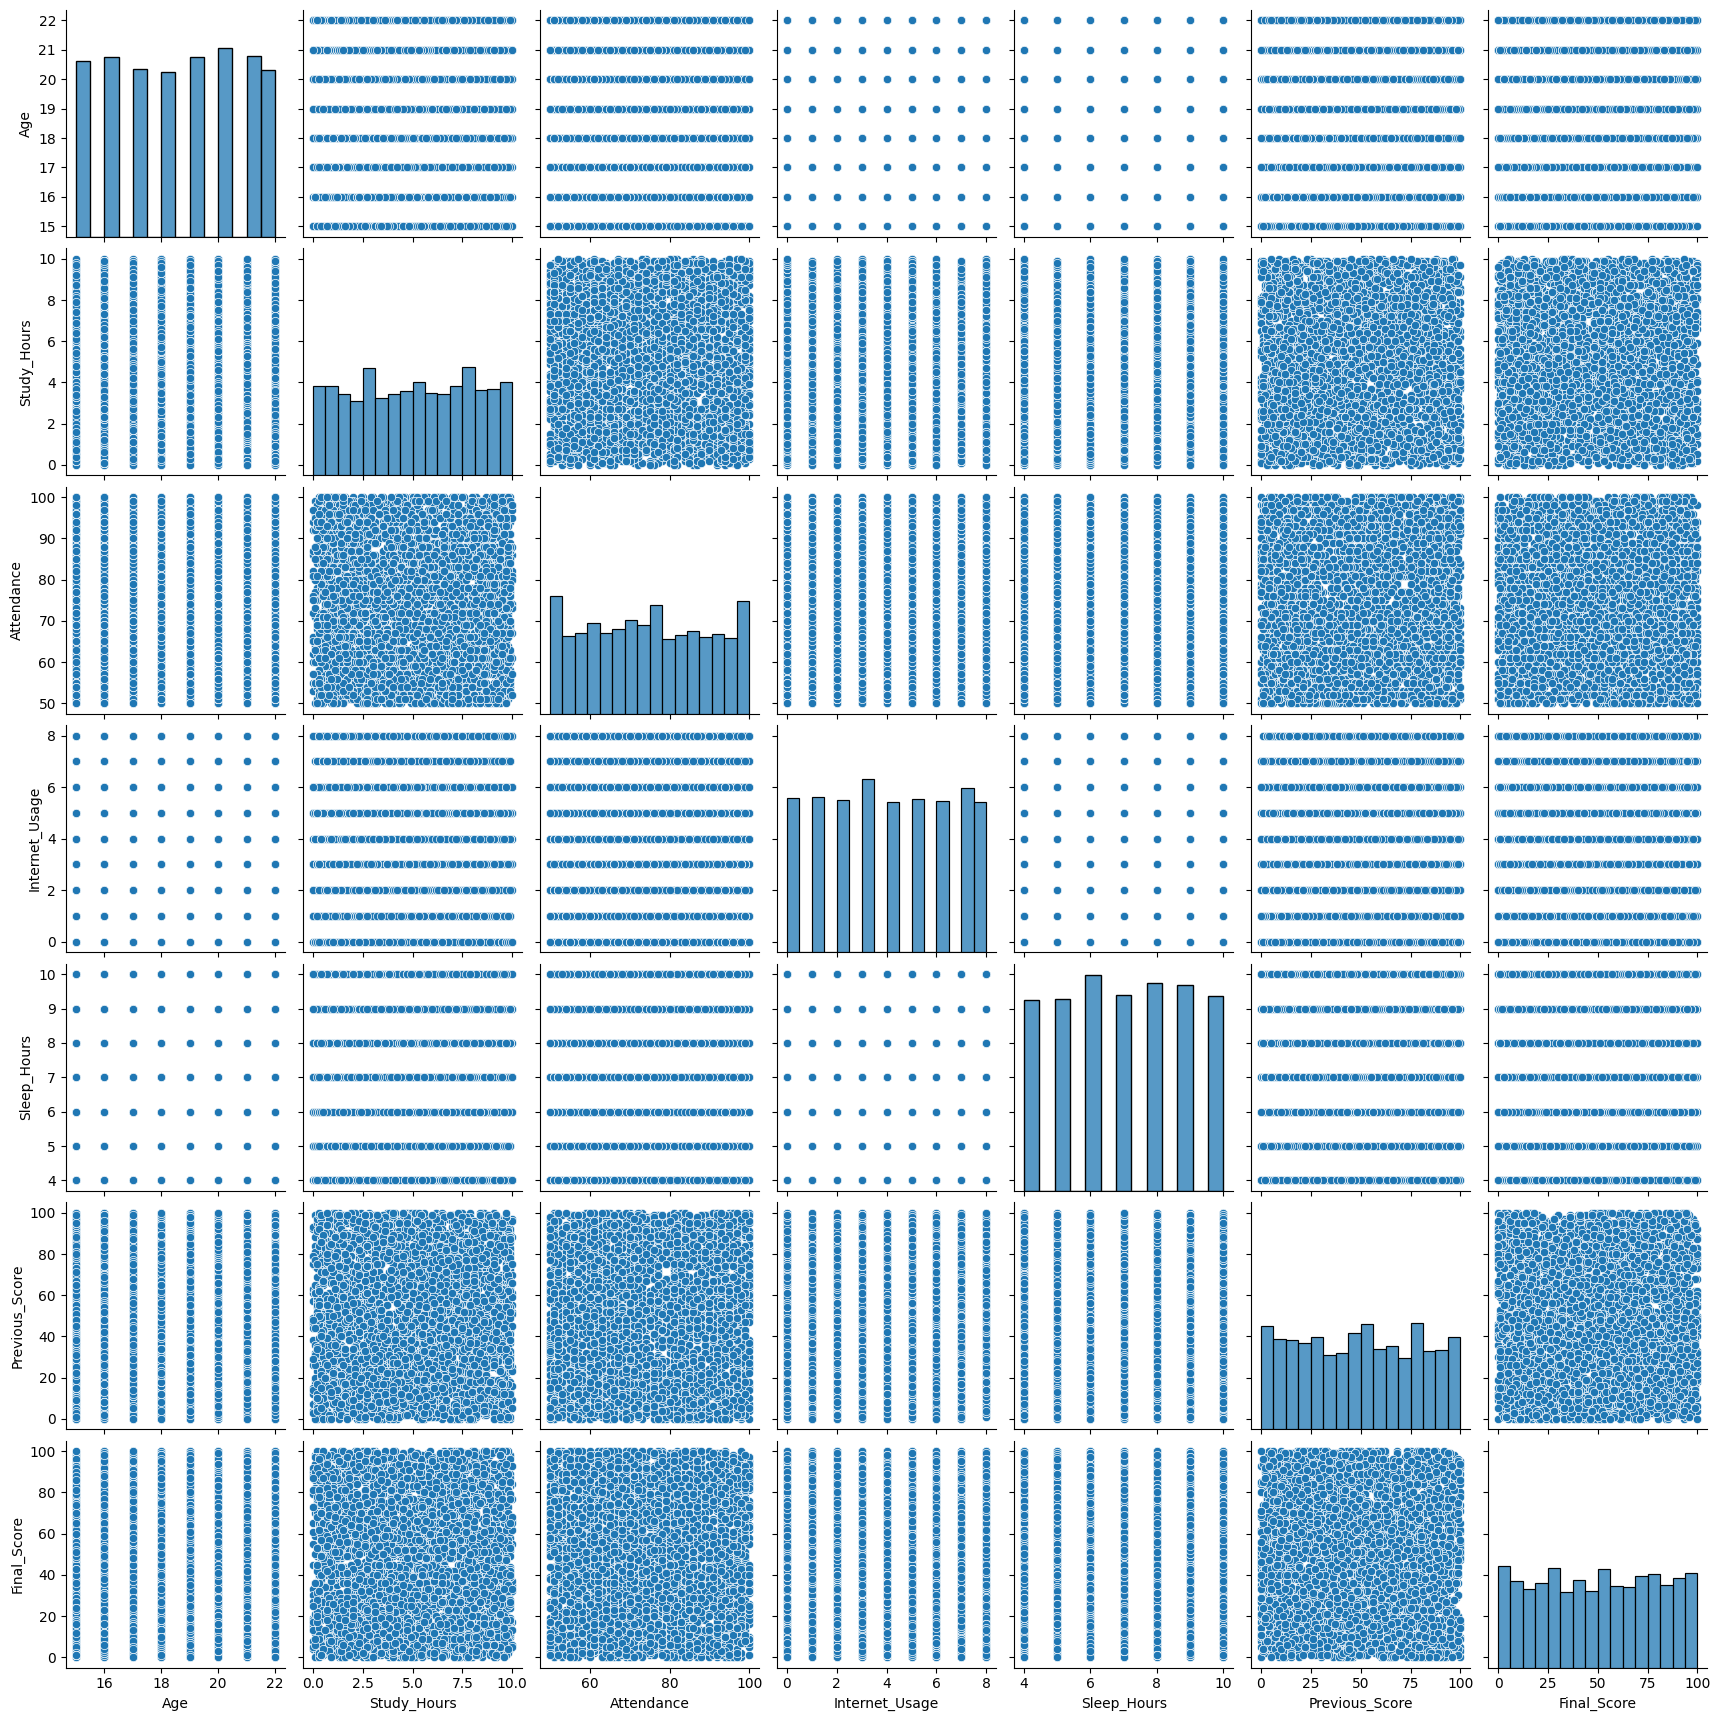

In [185]:
sns.pairplot(df)
plt.show()


In [186]:
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"]) 
df["Parental_Support"] = encoder.fit_transform(df["Parental_Support"]) 
df["Pass_Fail"] = encoder.fit_transform(df["Pass_Fail"]) 


In [187]:
X = df.drop(columns=["Student_ID", "Final_Score", "Pass_Fail"])
y = df["Pass_Fail"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 8)
Target shape: (4000,)


In [188]:
df.shape

(4000, 11)

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [190]:
X_train.shape

(3200, 8)

In [191]:
X_test.shape

(800, 8)

In [192]:
y_train.shape

(3200,)

In [193]:
y_test.shape

(800,)

In [194]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [195]:
y_pred = model.predict(X_test)

In [196]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 50.74999999999999


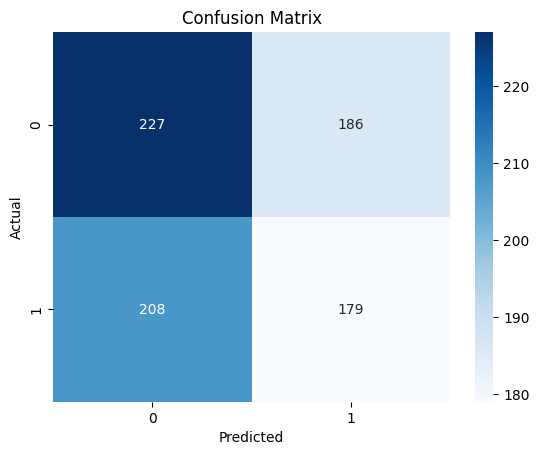

In [197]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [198]:
new_student = np.array([[18, 1, 6.5, 85, 2, 3, 7, 75]])  

prediction = model.predict(new_student)
print("Prediction (0=Fail, 1=Pass):", prediction[0])

Prediction (0=Fail, 1=Pass): 0


c:\Users\khana\OneDrive\Desktop\GPU t est in Tensorflow\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
